loan approval prediction
-----------------------------------
train accuracy: 0.825
test accuracy: 0.525
-----------------------------------
              precision    recall  f1-score   support

    rejected       0.33      0.06      0.10        18
    approved       0.54      0.91      0.68        22

    accuracy                           0.53        40
   macro avg       0.44      0.48      0.39        40
weighted avg       0.45      0.53      0.42        40



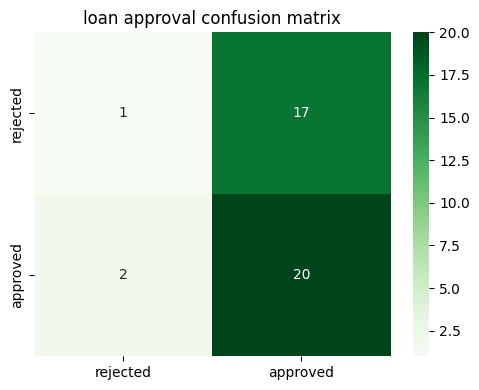

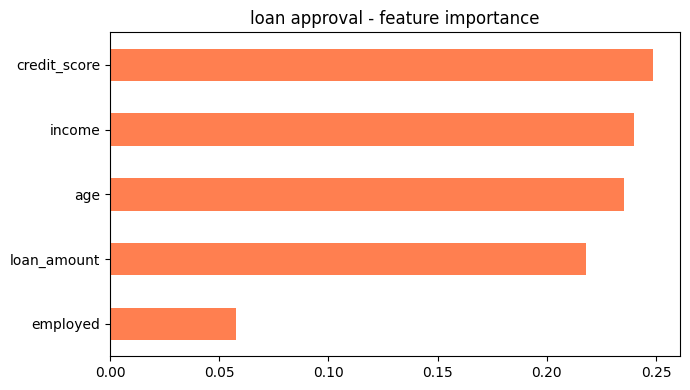

new applicant: approved!
confidence: 67.7 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200

data = {
    "age":        np.random.randint(21, 60, n),
    "income":     np.random.randint(15000, 200000, n),
    "loan_amount":np.random.randint(50000, 1000000, n),
    "credit_score":np.random.randint(300, 900, n),
    "employed":   np.random.choice([0, 1], n),
    "approved":   np.random.choice([0, 1], n, p=[0.35, 0.65])
}

df = pd.DataFrame(data)

x = df.drop("approved", axis=1)
y = df["approved"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100,
                                max_depth=5,
                                random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("loan approval prediction")
print("-" * 35)
print("train accuracy:", round(model.score(x_train, y_train), 3))
print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("-" * 35)
print(classification_report(y_test, y_pred,
      target_names=["rejected", "approved"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["rejected", "approved"],
            yticklabels=["rejected", "approved"])
plt.title("loan approval confusion matrix")
plt.tight_layout()
plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values()

importance.plot(kind="barh", color="coral", figsize=(7, 4))
plt.title("loan approval - feature importance")
plt.tight_layout()
plt.show()

new = [[35, 75000, 200000, 720, 1]]
result = model.predict(new)
prob = model.predict_proba(new)
print("new applicant:",
      "approved!" if result[0] == 1 else "rejected")
print("confidence:", round(max(prob[0]) * 100, 1), "%")